<a href="https://colab.research.google.com/github/ahamasmi-yoddhaha/ml_practice/blob/main/ml_sem5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Linear Regression

In [6]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [7]:
np.random.seed(0)
X=2*np.random.rand(100,1)
y=4+3*X+np.random.randn(100,1)

In [8]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [9]:
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [11]:
y_pred=model.predict(X_test)

In [12]:
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

In [13]:
print("Mean squared Error",mse)
print("R-squared score",r2)

Mean squared Error 0.9177532469714291
R-squared score 0.6521157503858556


In [14]:
import matplotlib.pyplot as plt

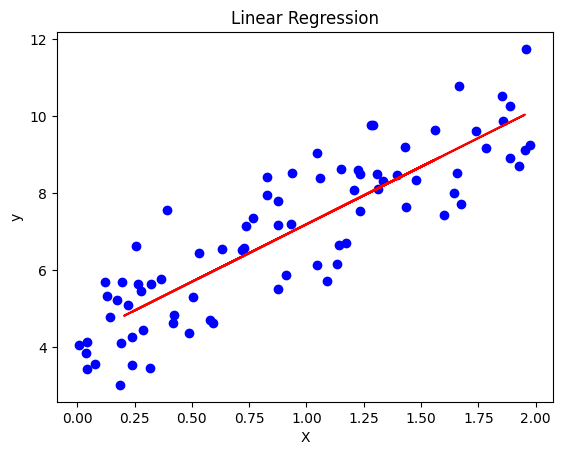

In [16]:
plt.scatter(X_train,y_train,color='blue')
plt.plot(X_test,y_pred,color='red')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression')
plt.show()

Logistic Regression

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import roc_curve,auc

In [22]:
data=load_breast_cancer()
X=data.data
y=data.target

In [23]:
x_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [24]:
model=LogisticRegression()
model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [25]:
probs=model.predict_proba(X_test)[:,1]

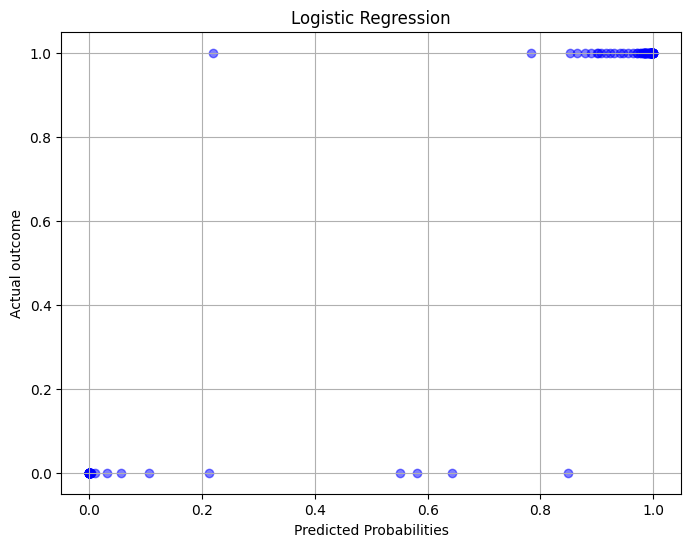

In [26]:
plt.figure(figsize=(8,6))
plt.scatter(probs,y_test,color='blue',alpha=0.5)
plt.xlabel('Predicted Probabilities')
plt.ylabel('Actual outcome')
plt.title('Logistic Regression')
plt.grid(True)
plt.show()

Decision Tree

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [30]:
data=load_breast_cancer()
X=data.data[:,:2]
y=data.target

In [31]:
x_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [32]:
model=DecisionTreeClassifier()
model.fit(x_train,y_train)

DecisionTreeClassifier()

In [33]:
y_pred=model.predict(X_test)

In [34]:
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy",accuracy)

Accuracy 0.868421052631579


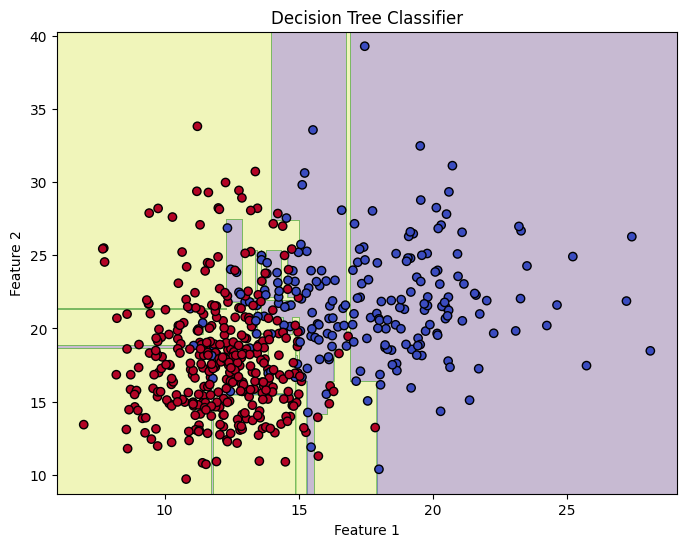

In [40]:
plt.figure(figsize=(8,6))
x_min,x_max=X[:,0].min()-1,X[:,0].max()+1
y_min,y_max=X[:,1].min()-1,X[:,1].max()+1
xx,yy=np.meshgrid(np.arange(x_min,x_max,0.01),np.arange(y_min,y_max,0.01))
Z=model.predict(np.c_[xx.ravel(),yy.ravel()])
Z=Z.reshape(xx.shape)
plt.contourf(xx,yy,Z,alpha=0.3)
plt.scatter(X[:,0],X[:,1],c=y,cmap=plt.cm.coolwarm,edgecolors='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Tree Classifier')
plt.show()

Example usage of pandas, Numpy and Scipy libraries


In [56]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind

In [57]:
data={
    'Group':['A','A','B','B','B','C','C','C'],
    'Value':[85,90,78,82,80,92,88,90]
}

In [58]:
df=pd.DataFrame(data)
print("Sample Dataset:")
print(df)
print()

Sample Dataset:
  Group  Value
0     A     85
1     A     90
2     B     78
3     B     82
4     B     80
5     C     92
6     C     88
7     C     90



In [59]:
print("Basic Data Analysis:")
print("Mean score from each group:")
print(df.groupby('Group')['Value'].mean())
print("Median score for each group:")
print(df.groupby('Group')['Value'].median())
print("standard deviation of scores for each group:")
print(df.groupby('Group')['Value'].std())
print()

Basic Data Analysis:
Mean score from each group:
Group
A    87.5
B    80.0
C    90.0
Name: Value, dtype: float64
Median score for each group:
Group
A    87.5
B    80.0
C    90.0
Name: Value, dtype: float64
standard deviation of scores for each group:
Group
A    3.535534
B    2.000000
C    2.000000
Name: Value, dtype: float64



In [60]:
print("T-test to compare scores between groups:")
group_a=df[df['Group']=='A']['Value']
group_b=df[df['Group']=='B']['Value']

T-test to compare scores between groups:


In [61]:
t_statistic,p_value=ttest_ind(group_a,group_b)
print("T-statistic:",t_statistic)
print("P-value:",p_value)
if p_value<0.05:
  print("The difference in scores between group a and group b is statistically significant.")
else:
  print("There is no statistically significant difference in scores between group a and group b")

T-statistic: 3.1429363309631024
P-value: 0.05154621068120146
There is no statistically significant difference in scores between group a and group b
